<a href="https://colab.research.google.com/github/marinasantiago1718/WikipediaGraph/blob/main/wikiVote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graduação em Ciência da Computação  
## Disciplina: Resolução de Problemas em Grafos  

**Docente:** Prof. Ricardo Carubbi  
**Instituição:** Universidade de Fortaleza  

---

# Caracterização Estrutural de Redes Reais  
## Verificação da Hipótese de Escala Livre

---

### Autores
- João Miguel Drumond
- Marina Maia  
- Tales Pimentel  
  

---

## 1. Introdução

Este projeto foi desenvolvido com o objetivo de aplicar os conhecimentos adquiridos na Unidade I da disciplina de Resolução de Problemas em Grafos, por meio da análise estrutural de uma rede real obtida da coleção SNAP.

A proposta central consiste em investigar se a rede selecionada apresenta propriedades associadas a grafos de escala livre, bem como discutir os limites dessa classificação dentro do domínio analisado.

---

## 2. Objetivos Específicos

1. Construir o grafo a partir de um dataset real do SNAP;
2. Calcular métricas estruturais fundamentais;
3. Estimar e analisar a distribuição de graus (escala log-log);
4. Comparar comportamentos entre domínios de rede;
5. Relacionar achados empíricos com conceitos teóricos de grafos complexos.

---

## 3. Dataset Selecionado

O dataset escolhido pertence à coleção disponibilizada pelo **Stanford Network Analysis Project (SNAP)**  (https://snap.stanford.edu/data/index.html).

Rede analisada:

**Wikipedia networks, articles, and metadata**, especificamente, o subconjunto **"wiki-Vote"**, que representa um sistema de votação para eleger um novo administrador. Assim, trata-se de um grafo direcionado.

### Contexto da Rede

Na Wikipédia, usuários podem se candidatar ao cargo de administrador por meio de um processo denominado *Request for Adminship (RfA)*. Durante esse processo, membros da comunidade votam para promover um candidato desejado para a posição.

Na rede modelada:

- Cada nó representa um usuário da Wikipédia;
- Uma aresta direcionada de $ i \rightarrow j $ indica que o usuário \( i \) votou no usuário \( j \).

Trata-se, portanto, de um grafo direcionado, representando interações sociais baseadas em votação.

### Análise de Rede
Primeiramente, por se tratar de uma rede de votação, o sistema é representado por um grafo direcionado, onde a orientação da aresta é fundamental. Isso se justifica pelo fato de que o fluxo de prestígio ocorre em um sentido específico: do eleitor para o candidato (relação "quem vota em quem").

Além disso, como cada eleitor possui o limite de apenas um voto por candidato, o grafo é não ponderado, uma vez que não há variação de peso ou intensidade nas conexões. Todos os votos possuem o mesmo valor unitário.

Nesse escopo, a rede é classificada como um grafo simples, pois não admite laços (self-loops) nem múltiplas arestas entre o mesmo par de nós: um usuário não pode votar em si mesmo e também não pode votar múltiplas vezes no mesmo candidato.

Por fim, trata-se de um grafo estático (não temporal). Embora as votações ocorram em momentos distintos cronologicamente, o modelo analisa a estrutura agregada das conexões, desconsiderando a evolução temporal.

---

### Estatísticas Estruturais do Dataset

- Número total de nós: 7.115
- Número total de arestas: 103.689
- Maior Componente Fracamente Conexa (WCC): 7.066 nós (99,3%)
- Maior Componente Fortemente Conexa (SCC): 1.300 nós (18,3%)
- Coeficiente médio de clusterização: 0.1409
- Número total de triângulos: 608.389
- Diâmetro da rede: 7
- Diâmetro efetivo (90%): 3.8

---

### Fonte

Leskovec, J.; Huttenlocher, D.; Kleinberg, J.  
*Signed Networks in Social Media*. CHI 2010.  
*Predicting Positive and Negative Links in Online Social Networks*. WWW 2010.

---
## 4. Tecnologias usadas
A análise foi conduzida com o uso combinado de Python e R, explorando as potencialidades específicas de cada linguagem ao longo do trabalho.

Para a manipulação estrutural da rede e o cálculo de métricas básicas, utilizou-se Python, por meio do repositório algs-py, inspirado na abordagem apresentada em Algorithms, 4th Edition, de Robert Sedgewick e Kevin Wayne. A biblioteca permite trabalhar com grafos direcionados utilizando listas de adjacência, facilitando o cálculo de propriedades como número de vértices, número de arestas, densidade, grau médio e coeficiente de clustering.

Para a etapa estatística e a análise da distribuição de graus, foi utilizado o software R, especialmente para geração de gráficos (incluindo representações log–log) e estimação de parâmetros como xmin, gamma e estatísticas de ajuste.

A modelagem das distribuições de cauda pesada foi realizada com o pacote poweRlaw, que permite ajustar distribuições do tipo lei de potência e compará-las com alternativas, como a log-normal, por meio de máxima verossimilhança, estatística de Kolmogorov–Smirnov e teste de razão de verossimilhança.

Adicionalmente, utilizou-se o pacote igraph para manipulação complementar da rede no ambiente R, bem como para apoio na extração e organização de métricas estruturais.

O uso combinado dessas ferramentas permitiu integrar análise algorítmica e modelagem estatística, proporcionando uma investigação mais robusta da estrutura da rede.

---

In [ ]:
!git clone https://github.com/shellfly/algs4-py.git

Cloning into 'algs4-py'...
remote: Enumerating objects: 437, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 437 (delta 121), reused 118 (delta 118), pack-reused 301 (from 1)
Receiving objects: 100% (437/437), 89.59 KiB | 1.23 MiB/s, done.
Resolving deltas: 100% (266/266), done.


Para facilitar a organização e a execução dos scripts, foi configurado um diretório padrão apontando para a pasta que reúne todos os arquivos de código utilizados no projeto. Essa configuração simplifica a importação de módulos e evita a necessidade de especificar caminhos completos ao longo da implementação.

In [ ]:
import sys
sys.path.append("/content/algs4-py")

---
## 5. Utilização do Dataset
O conjunto de dados disponibilizado pelo SNAP precisou passar por um processo de pré-processamento antes da análise. O arquivo original contém comentários, possíveis inconsistências estruturais e identificadores de nós não sequenciais, o que inviabiliza seu uso direto na implementação do grafo.

Assim, foi realizada uma etapa de limpeza com o objetivo de remover linhas de comentário; ignorar linhas vazias; identificar corretamente os vértices existentes; mapear os identificadores originais para um intervalo sequencial 0, ..., V - 1, conforme exigido pela classe Digraph.





In [ ]:
from algs4.digraph import Digraph

In [ ]:
def clean_wiki_dataset(input_path, output_path):
    edges = []
    nodes = set()

    with open(input_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            v, w = map(int, line.split())
            edges.append((v, w))
            nodes.add(v)
            nodes.add(w)

   # Mapeamento dos IDs

    sorted_nodes = sorted(list(nodes))
    mapping = {node_id: i for i, node_id in enumerate(sorted_nodes)}

    num_v = len(sorted_nodes)
    num_e = len(edges)

    # Salvar no formato esperado pela classe Digraph
    with open(output_path, 'w') as f:
        f.write(f"{num_v}\n")
        f.write(f"{num_e}\n")
        for v, w in edges:
            f.write(f"{mapping[v]} {mapping[w]}\n")

    print(f"Vértices: {num_v}, Arestas: {num_e}")
    print(f"Arquivo salvo em: {output_path}")

clean_wiki_dataset('Wiki-Vote.txt', 'Wiki-Vote-Clean.txt')

Vértices: 7115, Arestas: 103689
Arquivo salvo em: Wiki-Vote-Clean.txt


---
# 6. Métricas estruturais da rede
Antes da análise estatística da distribuição de graus, é importante caracterizar a estrutura global da rede por meio de métricas básicas de grafos.
- **Número de Vértices (V)**: representa a quantidade de indivíduos (ou nós) presentes na rede. Essa medida indica o tamanho do sistema analisado e serve como base para todas as demais métricas estruturais.
- **Número de Arestas (E)**: corresponde à quantidade total de conexões direcionadas entre os vértices. No contexto da rede Wiki-Vote, cada aresta representa um voto de um usuário para outro.

O conhecimento desses dois números é fundamental para iniciar a avaliação em cima dessa rede e calcular valores importantes, como densidade, grau médio.
- **Densidade**: mede o quão conectada a rede está em relação ao número máximo possível de conexões. Logo, nessa rede direcionada simples (sem laços), a densidade é calculada por E / V (V - 1).
- **Grau Médio**: indica, em média, quantas conexões cada vértice possui. Em grafos direcionados, cada aresta contribui +1 para grau de saída de um vértice e +1 para entrada de outro. Assim, a soma total dos graus de entrada é igual ao número total de arestas. Logo, o grau médio de entrada é E / V. O mesmo equivale ao grau de saída.

  Portanto, calcular E / V já fornece simultaneamente o grau médio de entrada e saída.Isso explica por que o grau médio total é numericamente igual ao grau médio de entrada quando considerado em termos globais.
- **Clustering Médio**:O coeficiente de clustering mede a tendência de formação de triângulos na rede. Em termos intuitivos, ele indica a probabilidade de que dois vizinhos de um vértice também estejam conectados entre si.

  No caso de grafos direcionados, o cálculo foi adaptado para considerar a existência de conexão entre vizinhos independentemente da direção da aresta, capturando assim a densidade local de interações.


In [ ]:


with open('Wiki-Vote-Clean.txt', 'r') as f:
    g = Digraph(file=f)


def total_arestas():
    return g.E

def total_vertices():
    return g.V

def densidade():
    return g.E / (g.V * (g.V - 1))


def grau_medio():
    return g.E / g.V


def clustering_medio_direcionado(g):
    V = g.V

    # Pré-computar vizinhos de saída
    out_adj = [set(g.adj[v]) for v in range(V)]

    # Construir vizinhos de entrada
    in_adj = [set() for _ in range(V)]
    for v in range(V):
        for w in g.adj[v]:
            in_adj[w].add(v)

    soma = 0

    for v in range(V):
        neighbors = out_adj[v] | in_adj[v]   # união
        k = len(neighbors)

        if k < 2:
            continue

        tri = 0
        neighbors_list = list(neighbors)

        for i in range(k):
            u = neighbors_list[i]
            for j in range(i+1, k):
                w = neighbors_list[j]

                # verificar aresta em qualquer direção
                if (w in out_adj[u]) or (u in out_adj[w]):
                    tri += 1

        soma += tri / (k * (k - 1))

    return soma / V



print(f"Total de vértices: {total_vertices()}")
print(f"Total de arestas: {total_arestas()}")
print(f"Densidade: {densidade()}")
print(f"Grau Médio: {grau_medio()}")
print("Clustering médio direcionado:", clustering_medio_direcionado(g))


Total de vértices: 7115
Total de arestas: 103689
Densidade: 0.0020485375110809584
Grau Médio: 14.573295853829936
Clustering médio direcionado: 0.07044892294654372


---
### Análise dos valores métricos obtidos
- **Ordem da rede**: com 7115 vértices, trata-se de uma rede de porte intermediário, suficientemente grande para apresentar padrões estruturais emergentes típicos de redes sociais reais, como heterogeneidade de graus e possível formação de comunidades.
- **Densidade**: o valor calculado de  0.002 significa que apenas 0,2% das conexões possíveis estão presentes. Como o número máximo de arestas seria 50 milhões ( V(V-1) ) e existem um pouco mais de 103mil observadas, a rede é claramente esparsa.
- **Grau Médio**: o valor de 14.67 significa que, em média, recebe e realiza 14 votos. Esse valor é mínimo considerando o tamanho da rede, reforçando o caráter esparso da estrutura.
- **Clustering Médio**: 0.0704 indica que há uma probabilidade de, aproximadamente, 7% de que dois vizinhos de um mesmo vértice estejam conectados entre si.Em redes sociais, clustering costuma indicar formação de grupos ou comunidades. Nesse contexto, o valor sugere alguma organização local, porém não extremamente forte.
---
### Conclusão
Os valores observados indicam que a rede é grande e esparsa; possui conectividade média moderada; apresenta algum grau de organização local; não é próxima de uma estrutura totalmente aleatória nem totalmente densa.
---

biblioteca do R para lidar com grafos

In [ ]:
install.packages("igraph")
library("igraph")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




Distribuição de graus P(k) em escala linear - (histograma normalizado);

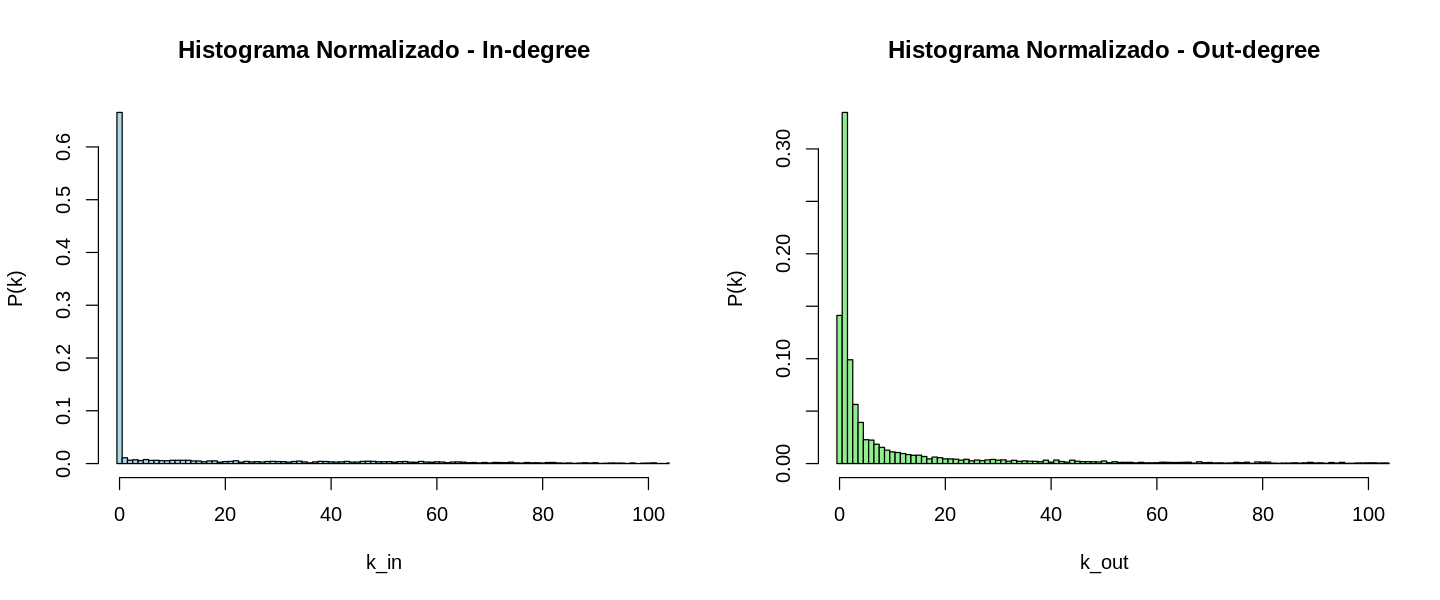

In [ ]:

library(igraph)
dados <- read.table("Wiki-Vote-Clean.txt", header = FALSE, skip = 2)

g <- graph_from_data_frame(dados, directed = TRUE)

k_in  <- degree(g, mode = "in")
k_out <- degree(g, mode = "out")

freq_in  <- table(k_in)
P_in     <- freq_in / sum(freq_in)
k_in_vals <- as.numeric(names(P_in))

freq_out  <- table(k_out)
P_out     <- freq_out / sum(freq_out)
k_out_vals <- as.numeric(names(P_out))

options(repr.plot.width = 12, repr.plot.height = 5)

par(mfrow = c(1,2))

hist(k_in,
     probability = TRUE,        # normaliza (área = 1)
     breaks = seq(min(k_in)-0.5, max(k_in)+0.5, by=1),
     xlim = c(0, 100),
     main = "Histograma Normalizado - In-degree",
     xlab = "k_in",
     ylab = "P(k)",
     col = "lightblue",
     border = "black")

hist(k_out,
     probability = TRUE,
     breaks = seq(min(k_out)-0.5, max(k_out)+0.5, by=1),
     xlim = c(0, 100),
     main = "Histograma Normalizado - Out-degree",
     xlab = "k_out",
     ylab = "P(k)",
     col = "lightgreen",
     border = "black")

### distribuição de graus P(k)- visualização em log-log;

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”
Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


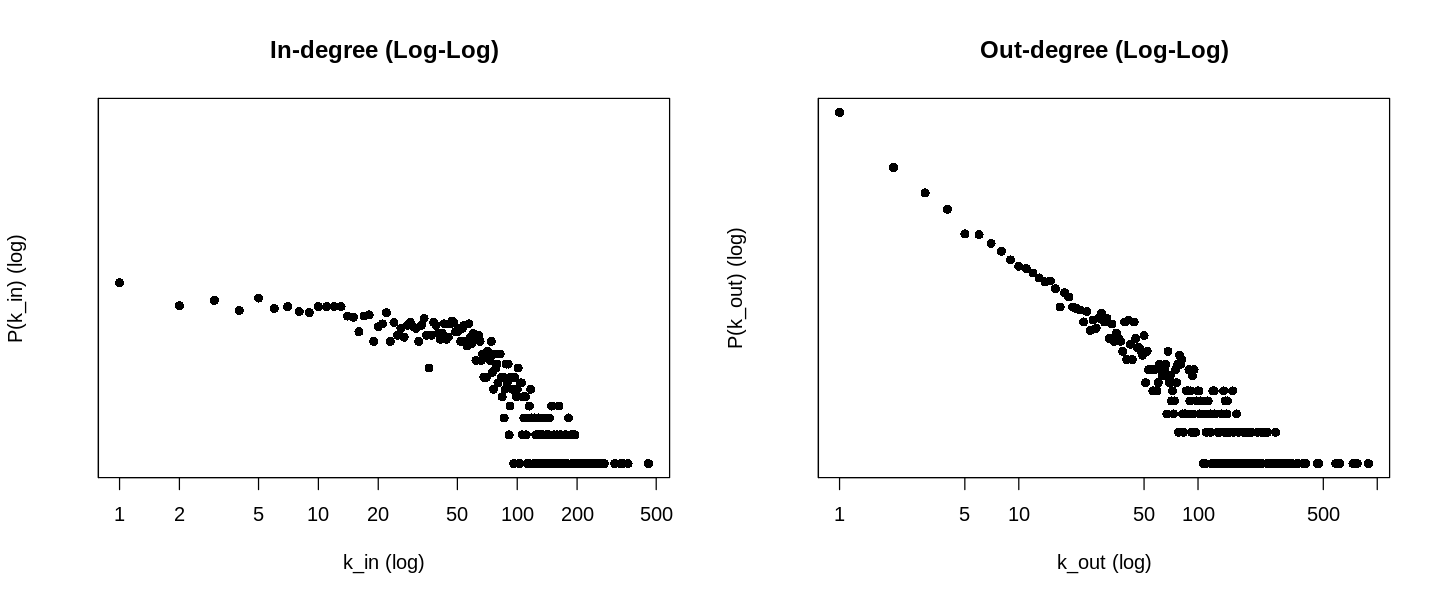

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 5)

par(mfrow = c(1,2))

plot(k_in_vals, P_in,
     log = "xy",
     pch = 16,
     xlab = "k_in (log)",
     ylab = "P(k_in) (log)",
     main = "In-degree (Log-Log)")

plot(k_out_vals, P_out,
     log = "xy",
     pch = 16,
     xlab = "k_out (log)",
     ylab = "P(k_out) (log)",
     main = "Out-degree (Log-Log)")

verificação do power law usando o pacote na distribuição in degree

In [ ]:
install.packages("poweRlaw")
library(poweRlaw)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘pracma’




[1] 3.62987

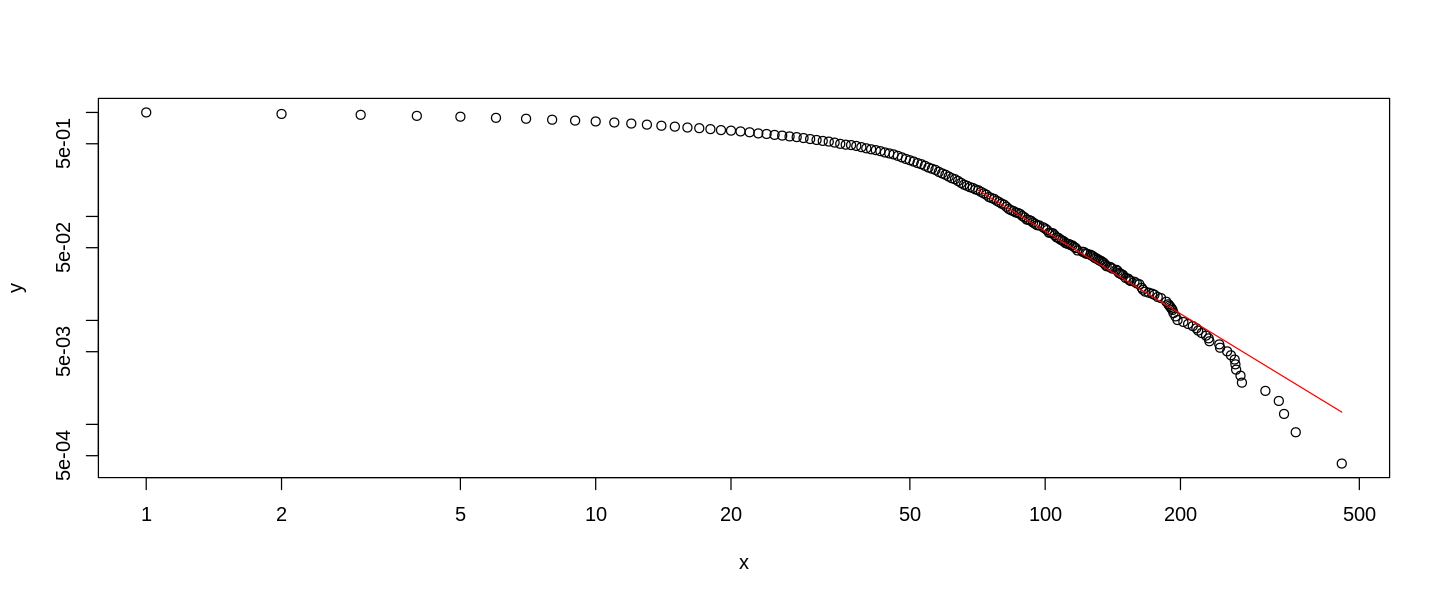

In [ ]:
# usar apenas k_in > 0 (zero não entra em power law)
k_in_pos <- k_in[k_in > 0]
pl_model <- displ$new(k_in_pos)

est <- estimate_xmin(pl_model)
pl_model$setXmin(est)

est_par <- estimate_pars(pl_model)
pl_model$setPars(est_par)
gamma <- pl_model$pars
gamma

plot(pl_model)
lines(pl_model, col="red")

modelo log-normal para comparar

In [ ]:
pl_model <- displ$new(k_in_pos) #uso do power law
est <- estimate_xmin(pl_model)
pl_model$setXmin(est)
est_par <- estimate_pars(pl_model)
pl_model$setPars(est_par)

# Criar log-normal
ln_model <- dislnorm$new(k_in_pos) #uso do log-normal

# IMPORTANTE: usar o mesmo xmin da power law
ln_model$setXmin(pl_model$xmin)

# Estimar parâmetros da log-normal com esse xmin fixo
est_ln_pars <- estimate_pars(ln_model)
ln_model$setPars(est_ln_pars)


comp <- compare_distributions(pl_model, ln_model)

n_tail <- sum(k_in_pos >= est$xmin)
prop_tail <- n_tail / length(k_in_pos)

print("R:")
comp$test_statistic
print("p-value")
comp$p_two_sided
print("xmin:")
pl_model$xmin
print("gamma:")
pl_model$pars
print("Ks:")
est$gof
print("N-cauda:")
n_tail
print("Proporção n-cauda:")
prop_tail


[1] "R:"


[1] -1.333835

[1] "p-value"


[1] 0.182258

[1] "xmin:"


...

[1] 0.02501155

[1] "N-cauda:"


[1] 425

[1] "Proporção n-cauda:"


[1] 0.1784964

Discussão: a rede pode ser considerada de escala livre? Em que medida?

Sim, o grafo do Wiki-Vote pode ser considerado de escala livre, na medida em que a maioria dos vértices possui baixo grau, enquanto uma minoria dos vértices são hubs, ou seja, vértices com muitas conexões.

Fazendo uma contextualização desses dados com o grafo Wiki-Vote, que representa os votos dos usuários para decidir quem serão os administradores da Wikipedia, onde os vértices são os usuários e as arestas são os votos, torna-se fácil perceber que a maioria das pessoas realiza poucos votos, enquanto uma minoria realiza muitos.

Essa desigualdade na distribuição dos graus caracteriza uma rede de escala livre, na qual poucos vértices concentram muitas conexões e a maioria possui poucas.